# Market Modeling and System Operation

This notebook adapts two of [PyPSA](https://pypsa.org)'s own official example notebooks to
Zambia:

1. Market Modeling — adapted from
   [`demand-supply-bids`](https://docs.pypsa.org/latest/examples/demand-supply-bids/),
   showing how a market operator clears competing generation and demand bids into a single
   price, first at a single node and then across two interconnected Zambian zones.
2. System Operation — adapted from
   [`scigrid-lopf-then-pf`](https://docs.pypsa.org/latest/examples/scigrid-lopf-then-pf/),
   showing how a system operator checks that an economically optimal dispatch is also
   *physically* feasible on the real network, using a non-linear power flow.
3. Solved network
   [`elec_s_all_ec_lv1.0_Co2L-3h.nc`](https://sandbox.zenodo.org/records/599530)


In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import pypsa
import logging
import networkx as nx
logging.getLogger("pypsa.contingency").setLevel(logging.ERROR)


## 1. Market Modeling

This section reproduces PyPSA's
[`demand-supply-bids`](https://docs.pypsa.org/latest/examples/demand-supply-bids/) example,
with the two market zones renamed **Copperbelt** and **Lusaka**, Zambia's two main demand
centres.

In [2]:
plt.style.use("bmh")
supply_bids = {
    "qty": [120, 100, 50, 60, 70, 60, 50],
    "price": [5, 15, 20, 36, 60, 150, 200],
}

demand_bids = {
    "qty": [250, 80, 20, 40, 60],
    "price": [200, 90, 75, 65, 24],
}

In [3]:
def clearing_point(supply_qty, supply_price, demand_qty, demand_price):
    """Quantity and price where the merit-order supply and demand curves cross."""
    s_cum = np.cumsum(supply_qty)
    d_cum = np.cumsum(demand_qty)
    q_max = int(min(s_cum[-1], d_cum[-1]))
    price, qty = supply_price[0], 0
    for q in range(1, q_max + 1):
        s_p = supply_price[np.searchsorted(s_cum, q)]
        d_p = demand_price[np.searchsorted(d_cum, q)]
        if s_p > d_p:
            break
        price, qty = s_p, q
    return qty, price

### Single market zone

First, we treat the whole country as a single .

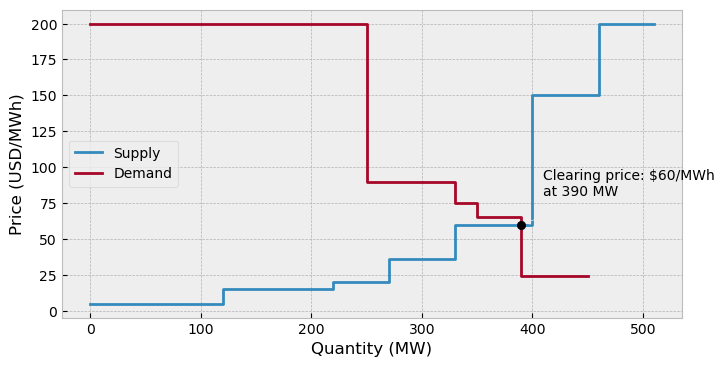

In [4]:
qty, price = clearing_point(
    supply_bids["qty"], supply_bids["price"], demand_bids["qty"], demand_bids["price"]
)

plt.figure(figsize=(8, 4))
plt.step(
    np.cumsum([0] + supply_bids["qty"]),
    supply_bids["price"][:1] + supply_bids["price"],
    label="Supply",
)
plt.step(
    np.cumsum([0] + demand_bids["qty"]),
    demand_bids["price"][:1] + demand_bids["price"],
    label="Demand",
)
plt.scatter([qty], [price], color="k", zorder=5)
plt.annotate(
    f"Clearing price: ${price}/MWh\nat {qty} MW",
    xy=(qty, price),
    xytext=(qty + 20, price + 20),
    arrowprops={"arrowstyle": "->"},
)
plt.xlabel("Quantity (MW)")
plt.ylabel("Price (USD/MWh)")
plt.legend()

PyPSA

In [5]:
n = pypsa.Network()
n.add("Bus", "Zambia")

# Add supply bids
n.madd(
    "Generator",
    names=[f"supply_{i}" for i in range(len(supply_bids["qty"]))],
    bus="Zambia",
    marginal_cost=supply_bids["price"],
    p_nom=supply_bids["qty"],
)

# Add demand bids
n.madd(
    "Generator",
    names=[f"demand_{i}" for i in range(len(demand_bids["qty"]))],
    bus="Zambia",
    p_nom=demand_bids["qty"],
    marginal_cost=[-p for p in demand_bids["price"]],
    sign=-1,
)

Index(['demand_0', 'demand_1', 'demand_2', 'demand_3', 'demand_4'], dtype='object')

In [6]:
n.optimize(solver_name="highs")

Index(['Zambia'], dtype='object', name='Bus')
Index(['Zambia'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.03s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 12 primals, 25 duals
Objective: -5.24e+04
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.


('ok', 'optimal')

The market-clearing objective, and the nodal balance constraint the Market Operator has to satisfy:

In [7]:
display(n.model.objective)
n.model.constraints["Bus-nodal_balance"]

Objective:
----------
LinearExpression: +5 Generator-p[now, supply_0] + 15 Generator-p[now, supply_1] + 20 Generator-p[now, supply_2] ... -75 Generator-p[now, demand_2] - 65 Generator-p[now, demand_3] - 24 Generator-p[now, demand_4]
Sense: min
Value: -52440.0

Constraint `Bus-nodal_balance` [Bus: 1, snapshot: 1]:
-----------------------------------------------------
[Zambia, now]: +1 Generator-p[now, supply_0] + 1 Generator-p[now, supply_1] + 1 Generator-p[now, supply_2] ... -1 Generator-p[now, demand_2] - 1 Generator-p[now, demand_3] - 1 Generator-p[now, demand_4] = -0.0

In [8]:
display(n.model.constraints["Generator-fix-p-upper"])
display(n.model.constraints["Generator-fix-p-lower"])

Constraint `Generator-fix-p-upper` [snapshot: 1, Generator-fix: 12]:
--------------------------------------------------------------------
[now, supply_0]: +1 Generator-p[now, supply_0] ≤ 120.0
[now, supply_1]: +1 Generator-p[now, supply_1] ≤ 100.0
[now, supply_2]: +1 Generator-p[now, supply_2] ≤ 50.0
[now, supply_3]: +1 Generator-p[now, supply_3] ≤ 60.0
[now, supply_4]: +1 Generator-p[now, supply_4] ≤ 70.0
[now, supply_5]: +1 Generator-p[now, supply_5] ≤ 60.0
[now, supply_6]: +1 Generator-p[now, supply_6] ≤ 50.0
[now, demand_0]: +1 Generator-p[now, demand_0] ≤ 250.0
[now, demand_1]: +1 Generator-p[now, demand_1] ≤ 80.0
[now, demand_2]: +1 Generator-p[now, demand_2] ≤ 20.0
[now, demand_3]: +1 Generator-p[now, demand_3] ≤ 40.0
[now, demand_4]: +1 Generator-p[now, demand_4] ≤ 60.0

Constraint `Generator-fix-p-lower` [snapshot: 1, Generator-fix: 12]:
--------------------------------------------------------------------
[now, supply_0]: +1 Generator-p[now, supply_0] ≥ -0.0
[now, supply_1]: +1 Generator-p[now, supply_1] ≥ -0.0
[now, supply_2]: +1 Generator-p[now, supply_2] ≥ -0.0
[now, supply_3]: +1 Generator-p[now, supply_3] ≥ -0.0
[now, supply_4]: +1 Generator-p[now, supply_4] ≥ -0.0
[now, supply_5]: +1 Generator-p[now, supply_5] ≥ -0.0
[now, supply_6]: +1 Generator-p[now, supply_6] ≥ -0.0
[now, demand_0]: +1 Generator-p[now, demand_0] ≥ -0.0
[now, demand_1]: +1 Generator-p[now, demand_1] ≥ -0.0
[now, demand_2]: +1 Generator-p[now, demand_2] ≥ -0.0
[now, demand_3]: +1 Generator-p[now, demand_3] ≥ -0.0
[now, demand_4]: +1 Generator-p[now, demand_4] ≥ -0.0

The single, uniform clearing price for the whole country, and the resulting dispatch:

In [9]:
n.buses_t.marginal_price

Bus,Zambia
snapshot,
now,60.0


In [10]:
n.generators_t.p

Generator,supply_0,supply_1,supply_2,supply_3,supply_4,supply_5,supply_6,demand_0,demand_1,demand_2,demand_3,demand_4
snapshot,,,,,,,,,,,,
now,120.0,100.0,50.0,60.0,60.0,-0.0,-0.0,250.0,80.0,20.0,40.0,-0.0


### Two zones: Copperbelt and Lusaka

Now we split supply and demand between the **Copperbelt** and **Lusaka**

In [11]:
supply_bids["zone"] = ["Copperbelt", "Lusaka", "Copperbelt", "Lusaka", "Lusaka", "Lusaka", "Lusaka"]
demand_bids["zone"] = ["Lusaka", "Copperbelt", "Copperbelt", "Lusaka", "Copperbelt"]

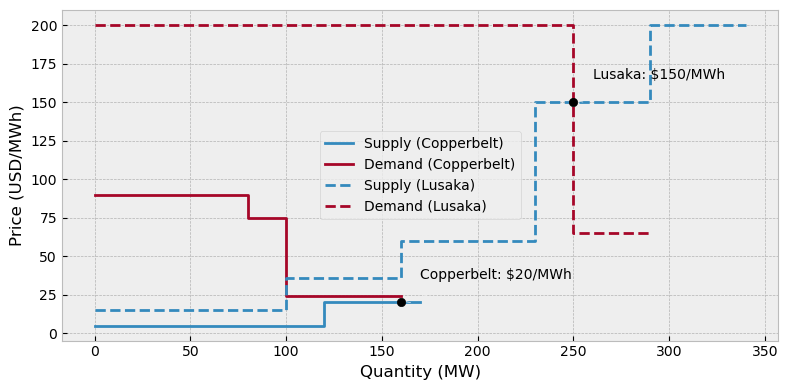

In [12]:
plt.figure(figsize=(8, 4))

for zone, linestyle in zip(["Copperbelt", "Lusaka"], ["-", "--"]):
    s_idx = [i for i, z in enumerate(supply_bids["zone"]) if z == zone]
    d_idx = [i for i, z in enumerate(demand_bids["zone"]) if z == zone]

    s_qty = [supply_bids["qty"][i] for i in s_idx]
    s_price = [supply_bids["price"][i] for i in s_idx]
    d_qty = [demand_bids["qty"][i] for i in d_idx]
    d_price = [demand_bids["price"][i] for i in d_idx]

    plt.step(
        np.cumsum([0] + s_qty),
        [s_price[0]] + s_price,
        label=f"Supply ({zone})",
        color="C0",
        linestyle=linestyle,
    )
    plt.step(
        np.cumsum([0] + d_qty),
        [d_price[0]] + d_price,
        label=f"Demand ({zone})",
        color="C1",
        linestyle=linestyle,
    )

    qty, price = clearing_point(s_qty, s_price, d_qty, d_price)
    plt.scatter([qty], [price], color="k", zorder=5)
    plt.annotate(
        f"{zone}: ${price}/MWh",
        xy=(qty, price),
        xytext=(qty + 10, price + 15),
        arrowprops={"arrowstyle": "->"},
    )

plt.xlabel("Quantity (MW)")
plt.ylabel("Price (USD/MWh)")
plt.legend()
plt.tight_layout()

Without any interconnection between the two zones, each clears independently.

PyPSA

In [13]:
n2 = pypsa.Network()

n2.add("Bus", "Copperbelt")
n2.add("Bus", "Lusaka")

n2.madd(
    "Generator",
    names=[f"supply_{i}" for i in range(len(supply_bids["qty"]))],
    bus=supply_bids["zone"],
    marginal_cost=supply_bids["price"],
    p_nom=supply_bids["qty"],
)
n2.madd(
    "Generator",
    names=[f"demand_{i}" for i in range(len(demand_bids["qty"]))],
    bus=demand_bids["zone"],
    p_nom=demand_bids["qty"],
    marginal_cost=[-p for p in demand_bids["price"]],
    sign=-1,
)

Index(['demand_0', 'demand_1', 'demand_2', 'demand_3', 'demand_4'], dtype='object')

In [14]:
n2.optimize(solver_name="highs")

Index(['Copperbelt', 'Lusaka'], dtype='object', name='Bus')
Index(['Copperbelt', 'Lusaka'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.02s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 12 primals, 26 duals
Objective: -4.79e+04
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.


('ok', 'optimal')

In [15]:
n2.buses_t.marginal_price

Bus,Copperbelt,Lusaka
snapshot,,
now,20.0,150.0


Splitting the market into two isolated zones destroys welfare relative to the single, national market:

In [16]:
display(n.objective)
display(n2.objective)

-52440.0

-47880.0

### Adding the Copperbelt–Lusaka transmission link

With a transmission line between the two zones, so power (and price convergence) can actually flow between the Copperbelt and Lusaka.

In [17]:
n2.add("Line", "Copperbelt-Lusaka", bus0="Copperbelt", bus1="Lusaka", s_nom=100)
n2.optimize(solver_name="highs")

Index(['Copperbelt-Lusaka'], dtype='object', name='Line')
Index(['Copperbelt-Lusaka'], dtype='object', name='Line')
Index(['Copperbelt-Lusaka'], dtype='object', name='Line')
Index(['Copperbelt', 'Lusaka'], dtype='object', name='Bus')
Index(['Copperbelt-Lusaka'], dtype='object', name='Line')
Index(['Copperbelt-Lusaka'], dtype='object', name='Line')
Index(['Copperbelt-Lusaka'], dtype='object', name='Line')
Index(['Copperbelt', 'Lusaka'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.09s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 13 primals, 28 duals
Objective: -5.24e+04
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper were not assigned to the network.


('ok', 'optimal')

In [18]:
display(n2.objective)
display(n2.buses_t.marginal_price)

-52440.0

Bus,Copperbelt,Lusaka
snapshot,,
now,60.0,60.0


With enough transfer capacity on the interconnecting line, the two zonal prices converge
back towards the single-market outcome.

## 2. System Operation

Clearing a market is not enough on its own System Operator function exists because a
dispatch that is economically optimal is not automatically physically feasible on the real
grid. Lines have thermal limits, an N-1 security margin needs to be kept in reserve for
contingencies, and voltage/reactive power has to stay within bounds.
This section reproduces PyPSA's
[`scigrid-lopf-then-pf`](https://docs.pypsa.org/latest/examples/scigrid-lopf-then-pf/) example, optimise dispatch with a linear model, then re-check it with a full non-linear power flow,
but on the actual PyPSA-Zambia network.


In [19]:

_candidates = [
    Path("../results/benchmark_run/networks/elec_s_all_ec_lv1.0_Co2L-3h.nc"),
    Path("results/benchmark_run/networks/elec_s_all_ec_lv1.0_Co2L-3h.nc"),
    Path(r"C:\Users\user\pypsa-zambia\results\benchmark_run\networks\elec_s_all_ec_lv1.0_Co2L-3h.nc"),
]
network_path = next((p for p in _candidates if p.exists()), _candidates[0])

n = pypsa.Network(str(network_path))
n

INFO:pypsa.io:Imported network elec_s_all_ec_lv1.0_Co2L-3h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units


PyPSA Network 'PyPSA-Earth'
Components:
 - Bus: 56
 - Carrier: 12
 - Generator: 73
 - GlobalConstraint: 2
 - Line: 107
 - Load: 56
 - StorageUnit: 10
Snapshots: 2920

Load Distribution

c:\Users\user\miniconda3\envs\pypsa-earth\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


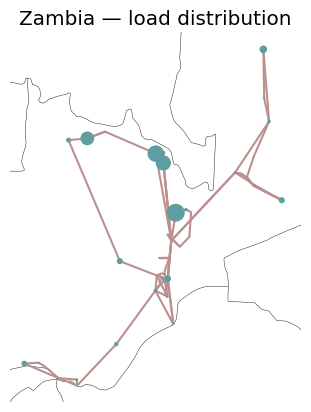

In [20]:
fig, ax = plt.subplots(
    1,
    1,
    subplot_kw={"projection": ccrs.EqualEarth()},
)

load_distribution = n.loads_t.p_set.iloc[0].groupby(n.loads.bus).sum()
n.plot(bus_sizes=load_distribution / 6000, ax=ax, title="Zambia — load distribution");

In [21]:
n.generators.groupby("carrier")["p_nom"].sum().round(1)

carrier
biomass            40.0
coal              330.0
load shedding    2697.8
oil               229.6
ror               138.8
solar             122.0
Name: p_nom, dtype: float64

In [22]:
n.storage_units.groupby("carrier")["p_nom"].sum().round(1)

carrier
hydro    3033.0
Name: p_nom, dtype: float64

c:\Users\user\miniconda3\envs\pypsa-earth\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
c:\Users\user\miniconda3\envs\pypsa-earth\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
c:\Users\user\miniconda3\envs\pypsa-earth\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
c:\Users\user\miniconda3\envs\pypsa-earth\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
c:\Users\user\miniconda3\envs\pypsa-earth\Lib\site-p

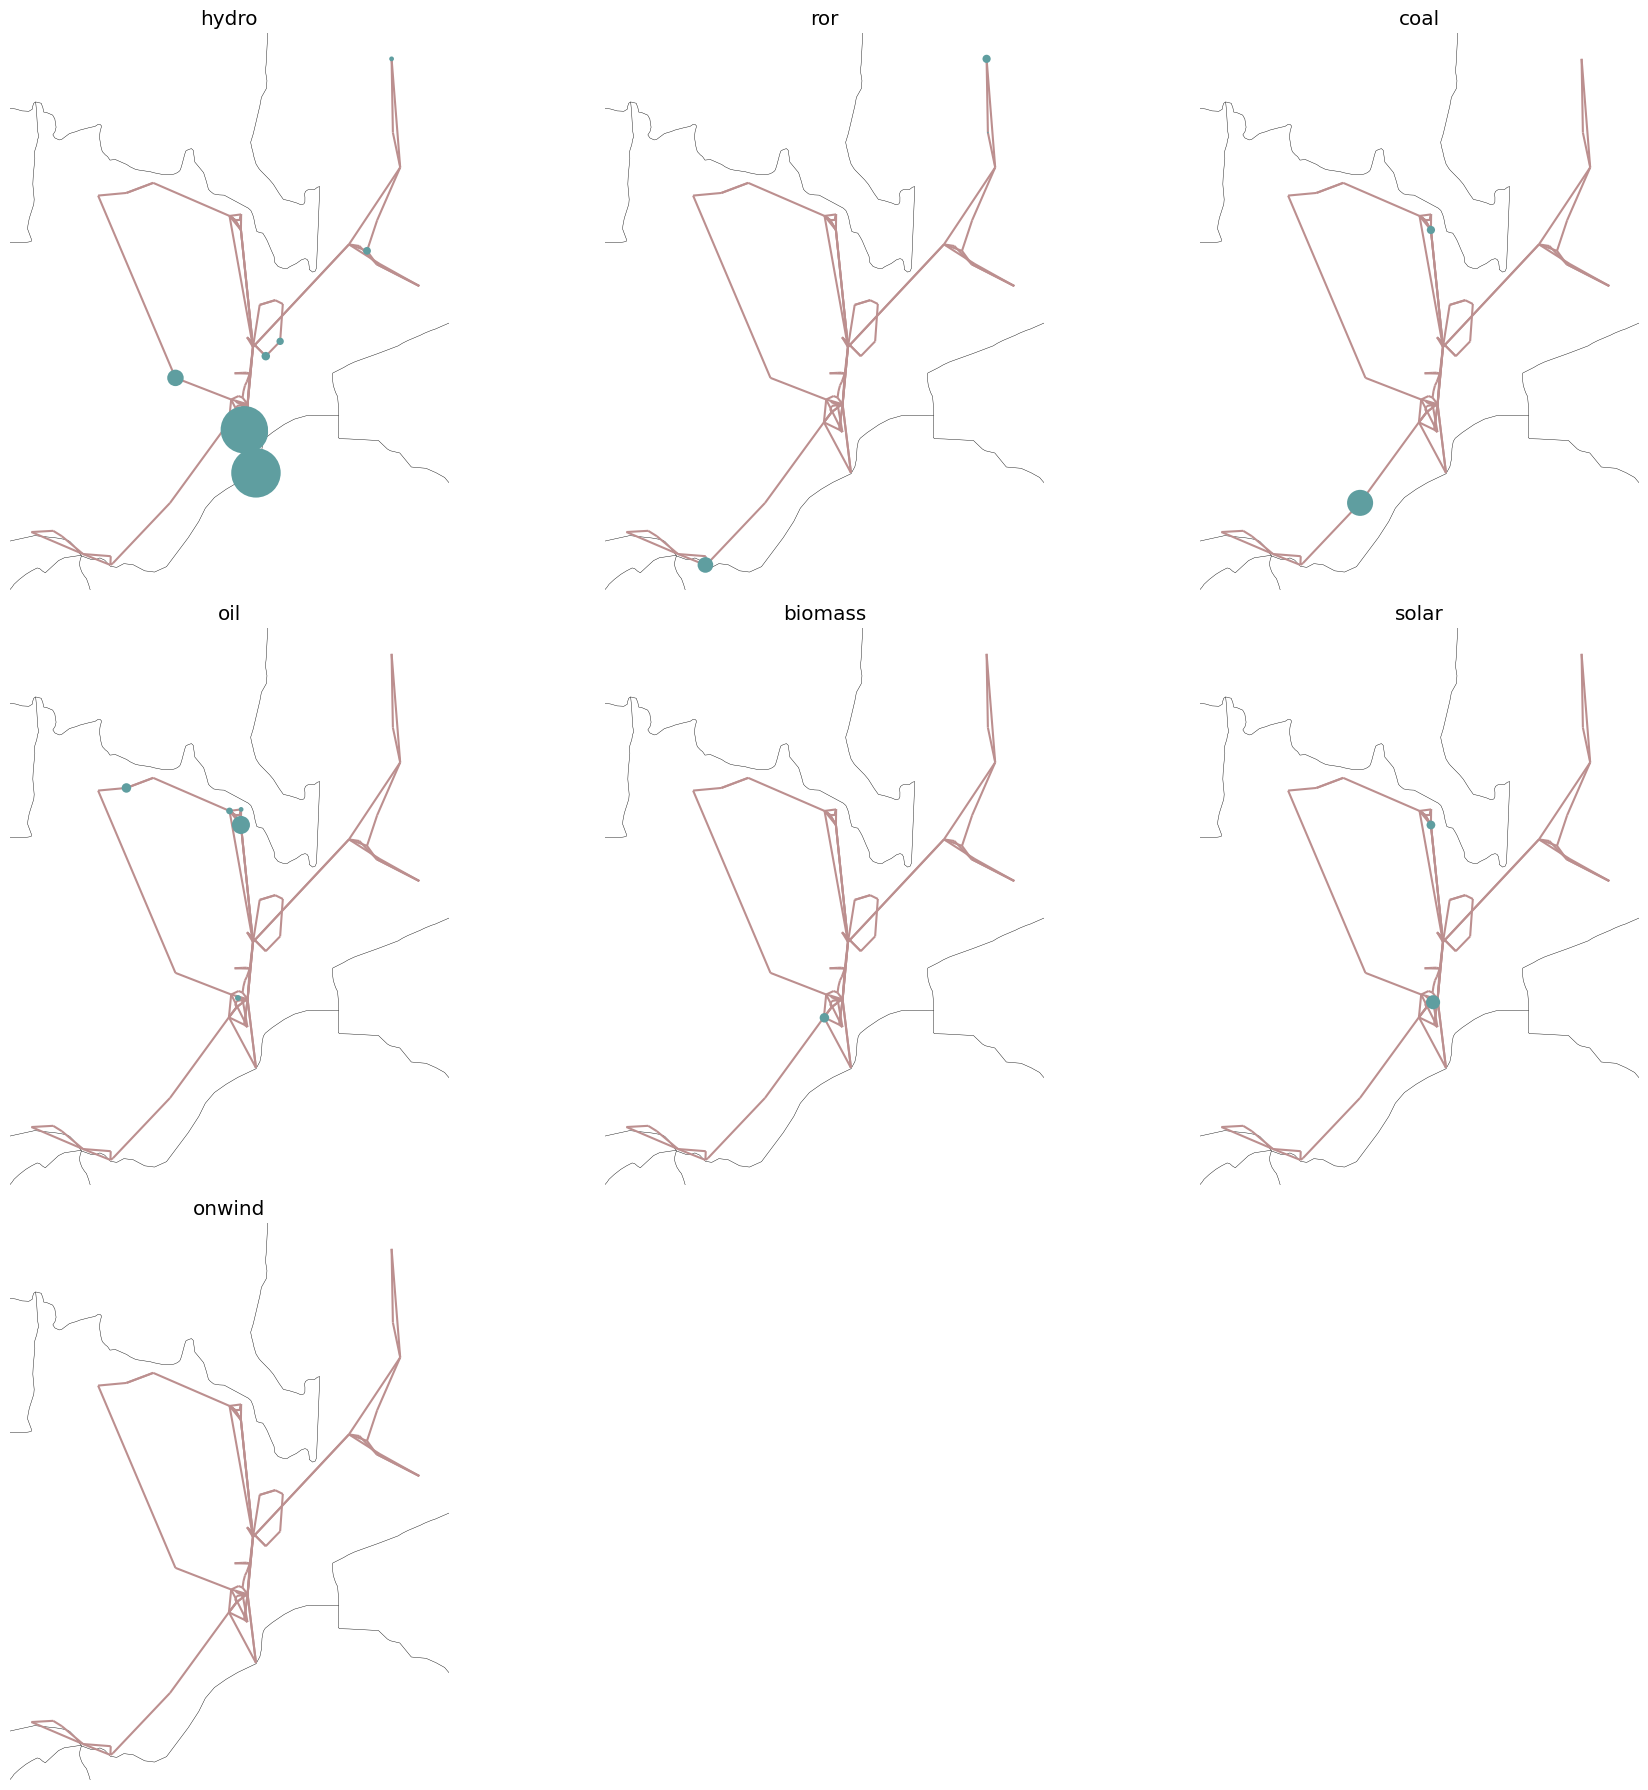

In [23]:
techs = ["hydro", "ror", "coal", "oil", "biomass", "solar", "onwind"]

n_graphs = len(techs)
n_cols = 3
if n_graphs % n_cols == 0:
    n_rows = n_graphs // n_cols
else:
    n_rows = n_graphs // n_cols + 1


fig, axes = plt.subplots(
    nrows=n_rows, ncols=n_cols, subplot_kw={"projection": ccrs.EqualEarth()}
)
size = 6
fig.set_size_inches(size * n_cols, size * n_rows)
axes = axes.flatten()

for i, tech in enumerate(techs):
    ax = axes[i]
    if tech in n.storage_units.carrier.unique():
        units = n.storage_units[n.storage_units.carrier == tech]
    else:
        units = n.generators[n.generators.carrier == tech]
    tech_distribution = (
        units.groupby("bus")["p_nom"].sum().reindex(n.buses.index, fill_value=0)
    )
    n.plot(ax=ax, bus_sizes=tech_distribution / 6000)
    ax.set_title(tech)

for j in range(len(techs), len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()

### Dispatch optimisation with an N-1 security margin

In [24]:
n.set_snapshots(n.snapshots[8:16])  # first day at 3-hourly resolution

contingency_factor = 0.7
n.lines.s_max_pu = contingency_factor

In [25]:
n.optimize(solver_name="highs")

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.24s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 1760 primals, 4305 duals
Objective: 8.70e+08
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

## Plot dispatch time series

In [26]:
p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
p_by_carrier = p_by_carrier.loc[:, (p_by_carrier != 0).any()]
p_by_carrier.columns

Index(['coal', 'load shedding', 'oil', 'ror', 'solar'], dtype='object', name='carrier')

Text(0.5, 0, '')

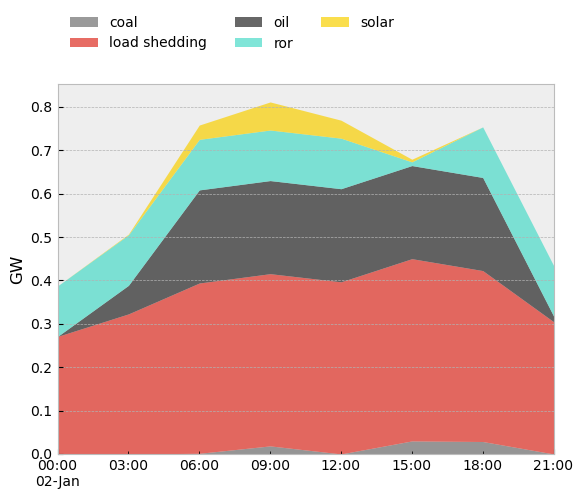

In [27]:
colors = n.carriers.color.reindex(p_by_carrier.columns)

fig, ax = plt.subplots()
p_by_carrier.div(1e3).plot(kind="area", ax=ax, lw=0, color=colors, alpha=0.7)
ax.legend(ncol=3, loc="upper left", bbox_to_anchor=(0, 1.02, 1, 0.2), frameon=False)
ax.set_ylabel("GW")
ax.set_xlabel("")

The chart above groups everything by carrier. Here is the same dispatch broken out by
individual named plant instead.

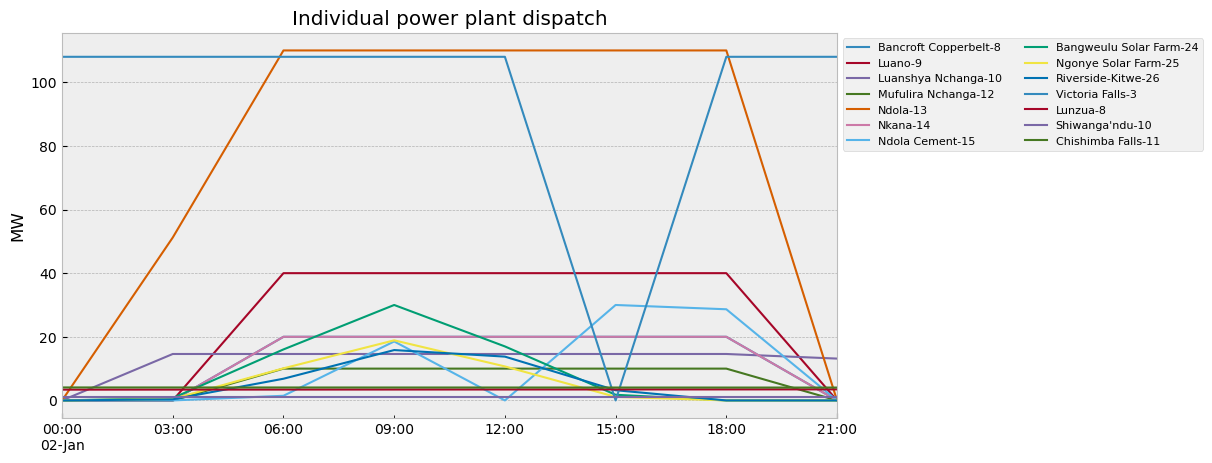

In [28]:
real_gens = n.generators[n.generators.carrier != "load shedding"].index
p_by_plant = n.generators_t.p[real_gens]
p_by_plant = p_by_plant.loc[:, (p_by_plant != 0).any()]

fig, ax = plt.subplots(figsize=(10, 5))
p_by_plant.plot(ax=ax, lw=1.5)
ax.legend(ncol=2, loc="upper left", bbox_to_anchor=(1.0, 1.0), fontsize=8)
ax.set_ylabel("MW")
ax.set_xlabel("")
ax.set_title("Individual power plant dispatch");

## Plot hydro storage time series

Text(0.5, 0, '')

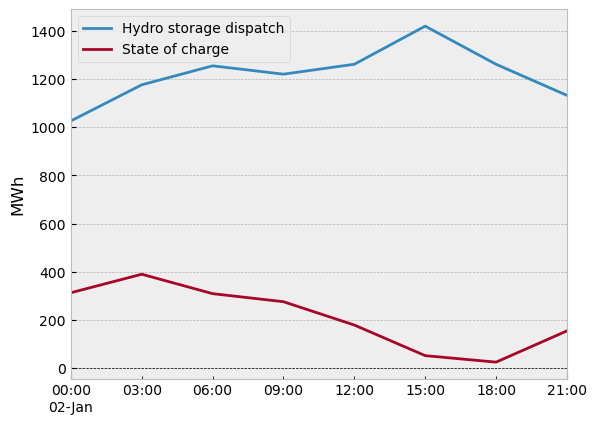

In [29]:
fig, ax = plt.subplots()

p_storage = n.storage_units_t.p.sum(axis=1)
state_of_charge = n.storage_units_t.state_of_charge.sum(axis=1)
p_storage.plot(label="Hydro storage dispatch", ax=ax)
state_of_charge.plot(label="State of charge", ax=ax)

ax.axhline(0, color="k", lw=0.5, ls="--")
ax.legend()
ax.set_ylabel("MWh")
ax.set_xlabel("")

Hydro Dispatch

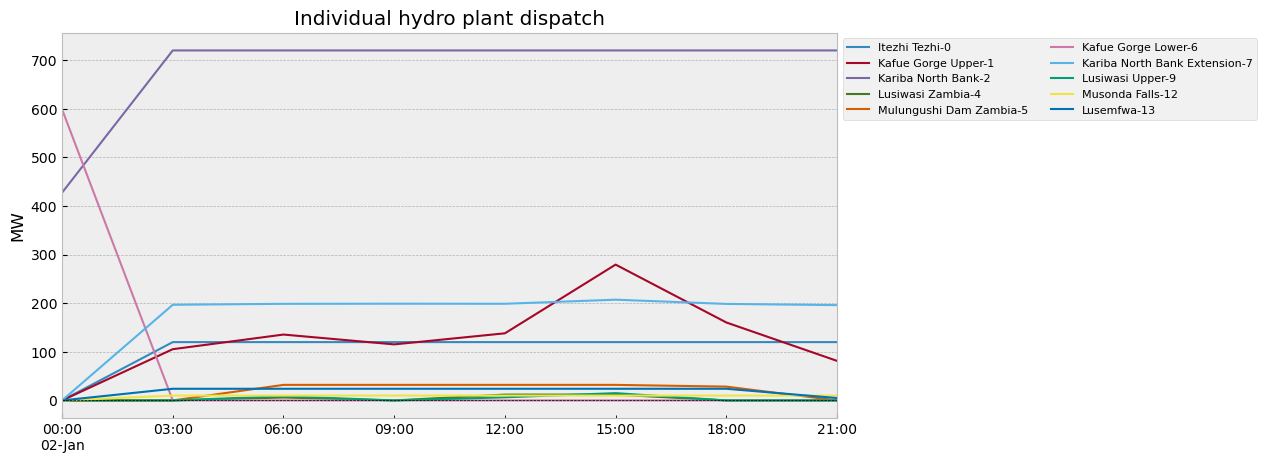

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
n.storage_units_t.p.plot(ax=ax, lw=1.5)
ax.legend(ncol=2, loc="upper left", bbox_to_anchor=(1.0, 1.0), fontsize=8)
ax.axhline(0, color="k", lw=0.5, ls="--")
ax.set_ylabel("MW")
ax.set_xlabel("")
ax.set_title("Individual hydro plant dispatch");

## Line loading from optimisation

With the linear power flow, there is the following per-unit loading at the fourth snapshot:

In [31]:
now = n.snapshots[4]
loading = n.lines_t.p0.loc[now] / n.lines.s_nom
loading.describe()

count    107.000000
mean      -0.006604
std        0.252554
min       -0.700000
25%       -0.147559
50%        0.028508
75%        0.114770
max        0.700000
dtype: float64

## Curtailment

In [32]:
carrier = "solar"

capacity = n.generators.groupby("carrier").sum().at[carrier, "p_nom"]
p_available = n.generators_t.p_max_pu.multiply(n.generators["p_nom"])
p_available_by_carrier = p_available.T.groupby(n.generators.carrier).sum().T
p_curtailed_by_carrier = p_available_by_carrier - p_by_carrier

In [33]:
p_df = pd.DataFrame(
    {
        carrier + " available": p_available_by_carrier[carrier],
        carrier + " dispatched": p_by_carrier[carrier],
        carrier + " curtailed": p_curtailed_by_carrier[carrier],
    }
)

p_df[carrier + " capacity"] = capacity
p_df.loc[p_df[carrier + " curtailed"] < 0, carrier + " curtailed"] = 0

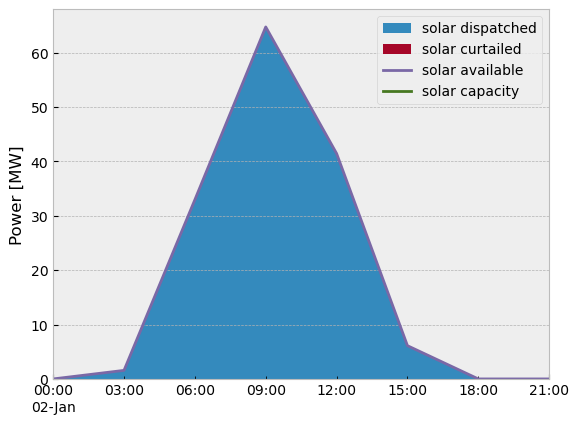

In [34]:
fig, ax = plt.subplots()
p_df[[carrier + " dispatched", carrier + " curtailed"]].plot(kind="area", ax=ax, lw=0)
p_df[[carrier + " available", carrier + " capacity"]].plot(ax=ax)

ax.set_xlabel("")
ax.set_ylabel("Power [MW]")
ax.legend()

## Non-linear power flow


In [35]:
n.optimize.fix_optimal_dispatch()

In [36]:
n.generators.loc[n.generators.control != "Slack", "control"] = "PV"
n.generators.control.value_counts()

control
PV       72
Slack     1
Name: count, dtype: int64

In [37]:
info = n.pf()

INFO:pypsa.pf:Performing non-linear load-flow on AC sub-network SubNetwork 0 for snapshots DatetimeIndex(['2013-01-02 00:00:00', '2013-01-02 03:00:00',
               '2013-01-02 06:00:00', '2013-01-02 09:00:00',
               '2013-01-02 12:00:00', '2013-01-02 15:00:00',
               '2013-01-02 18:00:00', '2013-01-02 21:00:00'],
              dtype='datetime64[ns]', name='snapshot', freq=None)
INFO:pypsa.pf:Newton-Raphson solved in 4 iterations with error of 0.000000 in 0.069641 seconds
INFO:pypsa.pf:Newton-Raphson solved in 4 iterations with error of 0.000000 in 0.060627 seconds
INFO:pypsa.pf:Newton-Raphson solved in 4 iterations with error of 0.000000 in 0.091834 seconds
INFO:pypsa.pf:Newton-Raphson solved in 4 iterations with error of 0.000000 in 0.085170 seconds
INFO:pypsa.pf:Newton-Raphson solved in 4 iterations with error of 0.000000 in 0.102359 seconds
INFO:pypsa.pf:Newton-Raphson solved in 4 iterations with error of 0.000000 in 0.077890 seconds
INFO:pypsa.pf:Newton-Raphson

Any failed to converge?

In [38]:
(~info.converged).any().any()

False

Line flows

In [39]:
n.lines_t.p0

,0,1,2,3,4,5,7,9,10,21,...,184,188,189,190,191,197,198,201,202,203
snapshot,,,,,,,,,,,,,,,,,,,,,
2013-01-02 00:00:00,-92.982615,-16.004629,-35.392524,36.794090,-16.364498,-154.014650,99.691079,4.430680,3.895441,2.560578,...,152.608486,-7.987015,-16.329353,0.069842,-59.703839,13.700242,12.603094,-9.473074,-7.721964,38.847733
2013-01-02 03:00:00,-104.063189,-8.664738,-44.107106,46.239414,-21.041850,-313.147685,120.625727,5.233493,4.595734,5.136150,...,43.457627,-9.510979,-21.939466,-9.505445,-66.856911,10.230636,12.683083,-10.193212,-8.475525,46.294472
2013-01-02 06:00:00,-92.086575,-8.811058,-48.067163,54.393582,-28.329757,-313.275465,123.587861,5.727345,4.964454,6.870400,...,51.481974,-11.382203,-24.199407,-13.873657,-74.640708,9.476250,15.465235,-13.868189,-10.624633,55.453192
2013-01-02 09:00:00,-91.123988,-9.336326,-49.651532,56.255092,-29.429353,-313.272523,124.145894,6.347107,5.576041,7.492147,...,49.421718,-11.487692,-24.548657,-15.265401,-82.870794,9.186670,16.707499,-12.834574,-10.745170,55.970005
2013-01-02 12:00:00,-91.584433,-8.766678,-48.791133,55.200760,-28.756402,-313.285725,124.122151,5.639590,4.870191,7.072302,...,52.308954,-11.482576,-24.414550,-14.410334,-73.549421,9.334388,15.754787,-14.303566,-10.738609,55.944944
2013-01-02 15:00:00,17.950913,-5.728341,-51.537412,58.257684,-30.365375,-313.281145,105.919539,5.507499,4.712628,7.938715,...,73.286432,-11.869789,-26.145129,-17.862224,-69.944195,7.807921,15.476807,-14.872381,-10.707146,57.842429
2013-01-02 18:00:00,-91.460805,-8.265690,-48.940185,55.457410,-29.002253,-313.259595,122.222360,6.294451,5.529676,6.034175,...,53.761782,-11.394514,-23.757634,-11.932188,-82.103242,9.955807,13.882582,-12.706986,-10.636048,55.513507
2013-01-02 21:00:00,-107.566310,-9.079183,-38.689839,40.125080,-17.710954,-313.084108,117.908663,4.863735,4.270205,4.198603,...,37.666932,-8.854285,-20.769852,-6.934110,-61.529880,10.898184,11.447339,-9.312531,-7.717191,43.084232


voltage angle differences across the lines

In [40]:
n.buses_t.v_ang * 180 / np.pi

Bus,2,5,6,8,10,13,16,20,22,26,...,131,132,133,138,145,146,147,149,152,155
snapshot,,,,,,,,,,,,,,,,,,,,,
2013-01-02 00:00:00,-13.225016,-2.977682,-0.523329,-3.714241,0.240697,-7.897555,1.678682,-13.485359,-12.108105,-13.524011,...,-4.932393,-4.733162,-5.474645,-11.703989,-11.379307,-2.356426,-10.309886,-3.361756,-3.655262,-3.966413
2013-01-02 03:00:00,-14.259717,-3.335603,2.533277,-4.226539,-0.297562,-8.549500,1.415176,-14.584212,-13.343746,-14.635404,...,-5.431212,-5.222604,-5.999836,-12.008176,-12.460416,-3.839075,-9.386689,-3.780604,-4.114376,-4.416535
2013-01-02 06:00:00,-14.034486,-2.948769,2.936941,-3.861541,-0.959473,-8.203124,1.090798,-14.388138,-13.600108,-14.476359,...,-5.070819,-4.859631,-5.647829,-11.442121,-12.357875,-3.402604,-7.954830,-3.377998,-3.712192,-4.038752
2013-01-02 09:00:00,-13.845885,-2.917714,2.972584,-3.834599,-0.996821,-8.170733,1.072485,-14.211204,-14.082539,-14.302865,...,-5.038713,-4.827579,-5.615661,-11.412360,-13.023181,-3.394010,-7.926946,-3.338215,-3.671742,-4.006611
2013-01-02 12:00:00,-14.044961,-2.932568,2.954149,-3.849279,-0.995009,-8.189671,1.073373,-14.403944,-13.526055,-14.493385,...,-5.056687,-4.845419,-5.633988,-11.431170,-12.225321,-3.382977,-7.945665,-3.360864,-3.695609,-4.023966
2013-01-02 15:00:00,-10.491121,0.570052,6.636044,-0.212448,-4.209542,-4.525990,-2.071287,-10.870327,-9.686579,-10.964352,...,-1.391942,-1.180988,-1.968702,-7.767159,-8.231011,0.440590,-4.254429,0.233657,-0.041044,-0.359647
2013-01-02 18:00:00,-13.839582,-2.928580,2.953636,-3.831286,-0.963831,-8.182180,1.088661,-14.199663,-14.040537,-14.290089,...,-5.050421,-4.838996,-5.628075,-11.450413,-12.989432,-3.352047,-8.062545,-3.366609,-3.700073,-4.017197
2013-01-02 21:00:00,-14.351744,-3.448908,2.414877,-4.319814,-0.065531,-8.644434,1.528797,-14.636358,-13.067917,-14.677788,...,-5.531164,-5.323253,-6.097405,-12.392410,-12.243029,-3.983940,-10.756000,-3.896842,-4.227642,-4.521598


Bus voltage

In [41]:
n.buses_t.v_mag_pu

Bus,2,5,6,8,10,13,16,20,22,26,...,131,132,133,138,145,146,147,149,152,155
snapshot,,,,,,,,,,,,,,,,,,,,,
2013-01-02 00:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2013-01-02 03:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2013-01-02 06:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2013-01-02 09:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2013-01-02 12:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2013-01-02 15:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2013-01-02 18:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2013-01-02 21:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## N-1 contingency analysis

The `s_max_pu = 0.7` security margin used in the dispatch optimisation only reserves a
generic buffer on every line, it does not prove that the network survives the loss of
any single line. An N-1 check simulates every individual line outage in turn and looks
for any other line that would then be overloaded, using PyPSA's linearised
`lpf_contingency`, which is fast enough to run across many outages.

A few lines are bridges in the network graph. losing one of them islands part of the grid.

In [42]:
G = nx.Graph()
G.add_edges_from(zip(n.lines.bus0, n.lines.bus1))
bridge_buses = set(nx.bridges(G))
bridge_lines = n.lines.index[
    n.lines.apply(
        lambda r: (r.bus0, r.bus1) in bridge_buses or (r.bus1, r.bus0) in bridge_buses,
        axis=1,
    )
]

print(
    f"{len(bridge_lines)} of {len(n.lines)} lines are structural single points of "
    "failure (losing one would island part of the network):"
)
bridge_lines.tolist()

5 of 107 lines are structural single points of failure (losing one would island part of the network):


['0', '42', '139', '183', '191']

In [43]:
n.optimize.fix_optimal_dispatch()
branch_outages = n.lines.index.difference(bridge_lines)
p0_contingency = n.lpf_contingency(now, branch_outages=branch_outages)
max_loading = abs(p0_contingency.divide(n.passive_branches().s_nom, axis=0)).max()
max_loading.sort_values(ascending=False)

INFO:pypsa.pf:Performing linear load-flow on AC sub-network SubNetwork 0 for snapshot(s) DatetimeIndex(['2013-01-02 12:00:00'], dtype='datetime64[ns]', name='snapshot', freq=None)


(Line, 80)     1.661587
(Line, 145)    1.556919
(Line, 167)    1.341438
(Line, 203)    1.245690
(Line, 166)    1.167690
                 ...   
(Line, 67)     0.700000
(Line, 68)     0.700000
(Line, 69)     0.700000
(Line, 72)     0.700000
(Line, 165)    0.700000
Length: 103, dtype: float64

In [44]:
violations = max_loading.drop("base", errors="ignore")
violations = violations[violations > 1].sort_values(ascending=False)

if violations.empty:
    print("No N-1 violations: every single line outage keeps all other lines within their rated capacity.")
else:
    print(f"{len(violations)} outage(s) would push another line beyond 100% of s_nom:")
    display(violations)

12 outage(s) would push another line beyond 100% of s_nom:


(Line, 80)     1.661587
(Line, 145)    1.556919
(Line, 167)    1.341438
(Line, 203)    1.245690
(Line, 166)    1.167690
(Line, 148)    1.156494
(Line, 5)      1.080422
(Line, 22)     1.080135
(Line, 138)    1.011662
(Line, 137)    1.011579
(Line, 136)    1.011557
(Line, 29)     1.000995
dtype: float64

### Security-constrained dispatch (SCLOPF)

The violations above show that a blanket margin does not, by itself, guarantee N-1 security. PyPSA's Security-Constrained LOPF (`n.optimize.optimize_security_constrained`) puts the requirement directly into the dispatch optimisation instead for the specified branch outages, it adds a constraint that no other passive branch may exceed its rating in that contingency. Comparing this against a plain economic dispatch at full line rating shows what N-1 security actually costs here.

In [45]:
n_unconstrained = pypsa.Network(str(network_path))
n_unconstrained.set_snapshots(n.snapshots)
n_unconstrained.lines.s_max_pu = 1.0
n_unconstrained.optimize(snapshots=now, solver_name="highs")
unconstrained_cost = n_unconstrained.statistics.opex().sum()
unconstrained_cost

INFO:pypsa.io:Imported network elec_s_all_ec_lv1.0_Co2L-3h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.32s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 220 primals, 539 duals
Objective: 1.13e+08
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


867858785.9184002

In [46]:
insecure_outages = pd.Index([name for _, name in violations.index])
n_sclopf = pypsa.Network(str(network_path))
n_sclopf.set_snapshots(n.snapshots)
n_sclopf.lines.s_max_pu = 1.0

n_sclopf.optimize.optimize_security_constrained(
    now, branch_outages=insecure_outages, solver_name="highs"
)
secure_cost = n_sclopf.statistics.opex().sum()

print(f"Unconstrained dispatch cost: {unconstrained_cost:,.0f}")
print(f"SCLOPF dispatch cost:        {secure_cost:,.0f}")
print(
    f"Cost of N-1 security:        {secure_cost - unconstrained_cost:,.2f} "
    f"({100 * (secure_cost - unconstrained_cost) / unconstrained_cost:.4f}%)"
)

INFO:pypsa.io:Imported network elec_s_all_ec_lv1.0_Co2L-3h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.2s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 220 primals, 3107 duals
Objective: 1.43e+08
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance, Line-fix-s-lower-security-for-Line-outage-in-SubNetwork 0, Line-fix-s-upper-security-for-Line-outage-in-SubNetwork 0 were not assigned to the network.


Unconstrained dispatch cost: 867,858,786
SCLOPF dispatch cost:        897,950,508
Cost of N-1 security:        30,091,721.71 (3.4674%)


Confirm the SCLOPF dispatch is now actually secure

In [47]:
n_sclopf.optimize.fix_optimal_dispatch()
p0_check = n_sclopf.lpf_contingency(now, branch_outages=insecure_outages)
max_loading_check = abs(p0_check.divide(n_sclopf.passive_branches().s_nom, axis=0)).max()
max_loading_check

INFO:pypsa.pf:Performing linear load-flow on AC sub-network SubNetwork 0 for snapshot(s) DatetimeIndex(['2013-01-02 12:00:00'], dtype='datetime64[ns]', name='snapshot', freq=None)


base           0.691682
(Line, 80)     1.000000
(Line, 145)    1.000000
(Line, 167)    0.691682
(Line, 203)    1.000000
(Line, 166)    0.750000
(Line, 148)    0.738804
(Line, 5)      1.000000
(Line, 22)     0.999734
(Line, 138)    1.000000
(Line, 137)    0.999918
(Line, 136)    0.999896
(Line, 29)     0.922144
dtype: float64